1 sample
https://www.youtube.com/watch?v=h6s61a_pqfM

## Download

In [1]:
# import os

# # Define paths for data storage
# data_dir = 'coco_data'
# images_dir = os.path.join(data_dir, 'images')
# annotations_dir = os.path.join(data_dir, 'annotations')

# os.makedirs(images_dir, exist_ok=True)
# os.makedirs(annotations_dir, exist_ok=True)

# # URL for COCO 2017 training images
# train_images_url = 'http://images.cocodataset.org/zips/train2017.zip'
# train_zip_path = os.path.join(data_dir, 'train2017.zip')

# # Ensure clean download: Remove existing potentially corrupted file
# if os.path.exists(train_zip_path):
#     print(f"Removing existing file: {train_zip_path}")
#     os.remove(train_zip_path)

# # Download and extract training images again
# print(f"Downloading {train_images_url}...")
# !wget {train_images_url} -P {data_dir}
# print(f"Extracting train2017.zip to {images_dir}/train2017...")
# !unzip -nq {train_zip_path} -d {images_dir}

# print("COCO 2017 train2017.zip download and extraction complete.")

In [2]:
import os

# Define paths for data storage
data_dir = 'coco_data'
images_dir = os.path.join(data_dir, 'images')
annotations_dir = os.path.join(data_dir, 'annotations')

os.makedirs(images_dir, exist_ok=True)
os.makedirs(annotations_dir, exist_ok=True)

# URLs for COCO 2017 dataset
train_images_url = 'http://images.cocodataset.org/zips/train2017.zip'
val_images_url = 'http://images.cocodataset.org/zips/val2017.zip'
annotations_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'

# Download and extract training images
print(f"Downloading {train_images_url}...")
!wget -nc {train_images_url} -P {data_dir}
print(f"Extracting train2017.zip to {images_dir}/train2017...")
!unzip -nq {os.path.join(data_dir, 'train2017.zip')} -d {images_dir}

# Download and extract validation images
print(f"Downloading {val_images_url}...")
!wget -nc {val_images_url} -P {data_dir}
print(f"Extracting val2017.zip to {images_dir}/val2017...")
!unzip -nq {os.path.join(data_dir, 'val2017.zip')} -d {images_dir}

# Download and extract annotations
print(f"Downloading {annotations_url}...")
!wget -nc {annotations_url} -P {data_dir}
print(f"Extracting annotations_trainval2017.zip to {annotations_dir}...")
!unzip -nq {os.path.join(data_dir, 'annotations_trainval2017.zip')} -d {annotations_dir}

print("COCO 2017 dataset download and extraction complete.")

--2026-04-04 14:30:20--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.166.65, 3.5.6.130, 16.15.188.5, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.166.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘coco_data/train2017.zip’

train2017.zip       100%[===================>]  18.01G  58.1MB/s    in 6m 42s  

2026-04-04 14:37:03 (45.9 MB/s) - ‘coco_data/train2017.zip’ saved [19336861798/19336861798]

Extracting train2017.zip to coco_data/images/train2017...
--2026-04-04 14:41:52--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.207.113, 16.15.207.204, 16.15.228.240, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.207.113|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
S

In [3]:
import json
import os

# Define paths for data storage (already defined in previous cells, but good for clarity)
data_dir = 'coco_data'
annotations_dir = os.path.join(data_dir, 'annotations')

# Adjust path for annotation files, assuming 'annotations' directory is nested
# This is a common structure for COCO datasets after unzipping.
annotations_path_prefix = os.path.join(annotations_dir, 'annotations')

# Load annotations file
annotations_file = os.path.join(annotations_path_prefix, 'instances_train2017.json')
print(f"Loading annotations from: {annotations_file}")

with open(annotations_file, 'r') as f:
    coco_annotations = json.load(f)

print("Annotations loaded successfully.")

# Display some information about the loaded annotations
print(f"Number of images: {len(coco_annotations['images'])}")
print(f"Number of annotations: {len(coco_annotations['annotations'])}")
print(f"Number of categories: {len(coco_annotations['categories'])}")


Loading annotations from: coco_data/annotations/annotations/instances_train2017.json
Annotations loaded successfully.
Number of images: 118287
Number of annotations: 860001
Number of categories: 80


## Tạo CSV

Tệp `animal_classification_data.csv` được xây dựng một cách tỉ mỉ bằng cách sử dụng dữ liệu chủ yếu từ **bộ dữ liệu COCO 2017**. Bộ dữ liệu toàn diện này cung cấp một bộ sưu tập phong phú các hình ảnh cùng với các chú thích và chú giải tương ứng.

### 1. Nguồn Dữ liệu Chính:

Các thành phần chính sau đây của bộ dữ liệu COCO 2017 đã được sử dụng:

*   **`instances_train2017.json`**: Tệp JSON này đóng vai trò là nguồn chính cho siêu dữ liệu hình ảnh và thông tin danh mục đối tượng. Nó chứa thông tin chi tiết về các đối tượng được chú thích trong mỗi hình ảnh, bao gồm ID danh mục và ID hình ảnh.
*   **`captions_train2017.json`**: Tệp JSON này cung cấp tất cả các chú thích liên quan cho các hình ảnh. Mỗi chú thích được liên kết với một `image_id` cụ thể.
*   **`train2017.zip`**: Lưu trữ này chứa các tệp hình ảnh thực tế (ví dụ: tệp `.jpg`) cho tập huấn luyện. Sau khi giải nén, các hình ảnh này được tổ chức thành thư mục `coco_data/images/train2017`.

### 2. Lọc và Trích xuất Dữ liệu Động vật (Từ `instances_train2017.json`):

Bước này tập trung vào việc trích xuất thông tin liên quan đến 5 lớp động vật mục tiêu: 'cat', 'dog', 'horse', 'sheep' và 'cow'.

1.  **Xác định các lớp động vật mục tiêu**: Một danh sách `target_animal_classes` được định nghĩa chứa tên của các loài động vật mong muốn.
2.  **Tạo ánh xạ ID danh mục**: Một từ điển (`category_id_to_name`) được tạo từ trường `categories` trong `coco_annotations` để ánh xạ `category_id` (ví dụ: `17`) sang `category_name` (ví dụ: 'cat').
3.  **Tạo ánh xạ ID hình ảnh**: Một từ điển khác (`image_id_to_filename`) được tạo từ trường `images` trong `coco_annotations` để ánh xạ `image_id` sang `file_name` tương ứng (ví dụ: `000000495357.jpg`).
4.  **Lọc chú thích**: Mã sẽ lặp qua từng chú thích trong `coco_annotations['annotations']`.
    *   Đối với mỗi chú thích, nó kiểm tra xem `category_id` của chú thích có nằm trong các `target_category_ids` đã được lọc trước hay không.
    *   Nếu chú thích thuộc một trong các lớp động vật mục tiêu, `image_id` và `category_name` tương ứng sẽ được lấy ra.
    *   Sử dụng `image_id`, `file_name` được tìm nạp từ ánh xạ `image_id_to_filename`.
    *   **`image_path`** được tạo bằng cách nối thư mục ảnh gốc (`coco_data/images/train2017`) với `file_name`.
    *   Một từ điển chứa `image_id`, `image_path` và `class` (tên danh mục) sẽ được thêm vào danh sách `extracted_animal_data`.

**Kết quả**: Danh sách `extracted_animal_data` chứa thông tin cơ bản về hình ảnh động vật (ID, đường dẫn và lớp) được lọc từ `instances_train2017.json`.

### 3. Tích hợp Chú thích Hình ảnh (Từ `captions_train2017.json`):

Bước này liên kết tất cả các chú thích có sẵn cho các hình ảnh động vật đã được lọc.

1.  **Tải tệp chú thích**: Tệp `captions_train2017.json` được tải vào `coco_captions`.
2.  **Tạo ánh xạ chú thích**: Một từ điển (`image_id_to_captions`) được tạo để ánh xạ mỗi `image_id` duy nhất tới một danh sách tất cả các chú thích liên quan của nó từ `coco_captions['annotations']`.
3.  **Kết hợp dữ liệu**: Mã sẽ lặp qua từng mục trong danh sách `extracted_animal_data` đã tạo trước đó.
    *   Đối với mỗi mục nhập hình ảnh, nó sẽ tìm nạp tất cả các chú thích liên quan từ `image_id_to_captions`.
    *   Nếu một hình ảnh có nhiều chú thích, mỗi chú thích sẽ tạo ra một hàng riêng biệt trong tập dữ liệu cuối cùng, với cùng `image_id`, `image_path` và `class` nhưng với `caption` khác nhau.
    *   Thông tin được kết hợp (`image_id`, `image_path`, `caption`, `class`) được thêm vào danh sách `final_animal_data`.

**Kết quả**: Danh sách `final_animal_data` chứa các hình ảnh động vật cùng với tất cả các chú thích liên quan của chúng, sẵn sàng để lưu vào tệp CSV.

### 4. Lưu dữ liệu vào Tệp CSV (`animal_classification_data.csv`):

Bước cuối cùng là lưu dữ liệu đã được xử lý vào một tệp CSV.

1.  **Chuyển đổi thành DataFrame**: Danh sách `final_animal_data` (là một danh sách các từ điển) được chuyển đổi thành một Pandas DataFrame (`df_animal_data`).
2.  **Định nghĩa tên tệp**: Tên tệp đầu ra được đặt là `animal_classification_data.csv`.
3.  **Lưu vào CSV**: DataFrame được lưu vào tệp CSV bằng phương thức `.to_csv()`, với `index=False` để đảm bảo rằng chỉ mục của DataFrame không được ghi dưới dạng một cột trong tệp CSV.

**Kết quả**: Tệp `animal_classification_data.csv` được tạo ra, chứa các cột `image_id`, `image_path`, `caption` và `class`, tổng hợp tất cả thông tin cần thiết.

In [4]:
import pandas as pd

# 1. Define a list of the target animal class names
target_animal_classes = ['cat', 'dog', 'horse', 'sheep', 'cow']

# 2. Create a dictionary that maps category IDs to their names
category_id_to_name = {cat['id']: cat['name'] for cat in coco_annotations['categories']}

# 3. Create another dictionary that maps image IDs to their filenames
image_id_to_filename = {img['id']: img['file_name'] for img in coco_annotations['images']}

# 4. Initialize an empty list to store the extracted data
extracted_animal_data = []

# Filter categories to only include target animal classes
target_category_ids = [cid for cid, cname in category_id_to_name.items() if cname in target_animal_classes]

# 5. Iterate through coco_annotations['annotations']. For each annotation:
for annotation in coco_annotations['annotations']:
    category_id = annotation['category_id']

    if not category_id in target_category_ids: continue

    # b. If it does, retrieve the image_id and the corresponding category_name.
    image_id = annotation['image_id']
    category_name = category_id_to_name[category_id]

    # c. Use the image_id to get the file_name from the image ID to filename mapping.
    file_name = image_id_to_filename.get(image_id)

    if file_name:
        # Construct the image_path assuming train2017 subfolder for training images
        # We are currently loading instances_train2017.json, so images will be in 'train2017'
        image_path = os.path.join(images_dir, 'train2017', file_name)

        # d. Store a dictionary containing the image_id, image_path, and the class
        extracted_animal_data.append({
            'image_id': image_id,
            'image_path': image_path,
            'class': category_name
        })

print(f"Extracted {len(extracted_animal_data)} annotations for target animal classes.")
# Display the first few entries to verify
if extracted_animal_data:
    print("First 5 extracted data entries:")
    for i in range(min(5, len(extracted_animal_data))):
        print(extracted_animal_data[i])
else:
    print("No data found for the specified animal classes.")

Extracted 34519 annotations for target animal classes.
First 5 extracted data entries:
{'image_id': 495357, 'image_path': 'coco_data/images/train2017/000000495357.jpg', 'class': 'dog'}
{'image_id': 116061, 'image_path': 'coco_data/images/train2017/000000116061.jpg', 'class': 'dog'}
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'class': 'dog'}
{'image_id': 205350, 'image_path': 'coco_data/images/train2017/000000205350.jpg', 'class': 'dog'}
{'image_id': 74, 'image_path': 'coco_data/images/train2017/000000000074.jpg', 'class': 'dog'}


In [5]:
import json
import os
import pandas as pd

# Define paths (already defined, but good for clarity in this step)
data_dir = 'coco_data'
annotations_dir = os.path.join(data_dir, 'annotations')
images_dir = os.path.join(data_dir, 'images')

# Adjust path for annotation files, assuming 'annotations' directory is nested
annotations_path_prefix = os.path.join(annotations_dir, 'annotations')

# Load captions file
captions_file = os.path.join(annotations_path_prefix, 'captions_train2017.json')
print(f"Loading captions from: {captions_file}")

with open(captions_file, 'r') as f:
    coco_captions = json.load(f)

print("Captions loaded successfully.")
print(f"Number of caption annotations: {len(coco_captions['annotations'])}")

# Create a dictionary mapping image_id to a list of captions
image_id_to_captions = {}
for ann in coco_captions['annotations']:
    image_id = ann['image_id']
    caption = ann['caption']
    if image_id not in image_id_to_captions:
        image_id_to_captions[image_id] = []
    image_id_to_captions[image_id].append(caption)

print(f"Created caption mapping for {len(image_id_to_captions)} unique images.")

# Merge caption information with the extracted animal data
final_animal_data = []
for entry in extracted_animal_data:
    img_id = entry['image_id']
    image_path = entry['image_path']
    animal_class = entry['class']

    captions = image_id_to_captions.get(img_id, ['No caption available'])

    for caption in captions:
        final_animal_data.append({
            'image_id': img_id,
            'image_path': image_path,
            'caption': caption,
            'class': animal_class
        })

print(f"Final dataset contains {len(final_animal_data)} entries after adding captions.")

# Display the first few entries of the final data to verify
if final_animal_data:
    print("First 5 final data entries:")
    for i in range(min(5, len(final_animal_data))):
        print(final_animal_data[i])
else:
    print("No final data generated.")

Loading captions from: coco_data/annotations/annotations/captions_train2017.json
Captions loaded successfully.
Number of caption annotations: 591753
Created caption mapping for 118287 unique images.
Final dataset contains 172679 entries after adding captions.
First 5 final data entries:
{'image_id': 495357, 'image_path': 'coco_data/images/train2017/000000495357.jpg', 'caption': 'A dog sitting on top of a motorcycle in an intersection.', 'class': 'dog'}
{'image_id': 495357, 'image_path': 'coco_data/images/train2017/000000495357.jpg', 'caption': 'A monkey is riding a motorcycle down the road.', 'class': 'dog'}
{'image_id': 495357, 'image_path': 'coco_data/images/train2017/000000495357.jpg', 'caption': 'A group of people watch a dog ride a motorcycle. ', 'class': 'dog'}
{'image_id': 495357, 'image_path': 'coco_data/images/train2017/000000495357.jpg', 'caption': 'a person walking behind a motorcycle with a dog on it ', 'class': 'dog'}
{'image_id': 495357, 'image_path': 'coco_data/images/tr

In [6]:
df_animal_data = pd.DataFrame(final_animal_data)
df_animal_data.head()

# lúc này có person nên có text nhìn lạ

,image_id,image_path,caption,class
0,495357,coco_data/images/train2017/000000495357.jpg,A dog sitting on top of a motorcycle in an int...,dog
1,495357,coco_data/images/train2017/000000495357.jpg,A monkey is riding a motorcycle down the road.,dog
2,495357,coco_data/images/train2017/000000495357.jpg,A group of people watch a dog ride a motorcycle.,dog
3,495357,coco_data/images/train2017/000000495357.jpg,a person walking behind a motorcycle with a do...,dog
4,495357,coco_data/images/train2017/000000495357.jpg,A dog rides on a motorcycle while a man walks ...,dog


## Xác định và Loại trừ Hình ảnh có Người
lần này 5 class động vật và ko có người

In [7]:
import json

# 1. Find the category_id for 'person'
person_category_id = -1
for cat in coco_annotations['categories']:
    if cat['name'] == 'person':
        person_category_id = cat['id']
        break

if person_category_id == -1:
    print("Error: 'person' category not found in annotations.")
else:
    print(f"'person' category_id: {person_category_id}")

    # 2. Initialize an empty set to store unique image_ids with 'person' annotations
    image_ids_with_person = set()

    # 3. Iterate through each annotation and check if its category_id matches the 'person' category_id
    for annotation in coco_annotations['annotations']:
        if annotation['category_id'] == person_category_id:
            # 4. If it matches, add the image_id to the set
            image_ids_with_person.add(annotation['image_id'])

    # 5. Convert the set to a list
    image_ids_with_person_list = list(image_ids_with_person)

    print(f"Found {len(image_ids_with_person_list)} unique image_ids containing 'person' annotations.")
    print("First 5 image_ids with person (if any):")
    for i in range(min(5, len(image_ids_with_person_list))):
        print(image_ids_with_person_list[i])

'person' category_id: 1
Found 64115 unique image_ids containing 'person' annotations.
First 5 image_ids with person (if any):
262145
262146
524291
262148
393223


In [8]:
import pandas as pd

# 1. Define a list of the target animal class names
target_animal_classes = ['cat', 'dog', 'horse', 'sheep', 'cow']

# 2. Create a dictionary that maps category IDs to their names
category_id_to_name = {cat['id']: cat['name'] for cat in coco_annotations['categories']}

# 3. Create another dictionary that maps image IDs to their filenames
image_id_to_filename = {img['id']: img['file_name'] for img in coco_annotations['images']}

# 4. Initialize an empty list to store the extracted data
extracted_animal_data = []

# Filter categories to only include target animal classes
target_category_ids = [cid for cid, cname in category_id_to_name.items() if cname in target_animal_classes]

# 5. Iterate through coco_annotations['annotations']. For each annotation:
for annotation in coco_annotations['annotations']:
    category_id = annotation['category_id']

    # a. Check if its category_id corresponds to one of the target animal classes
    if category_id in target_category_ids:
        # b. If it does, retrieve the image_id and the corresponding category_name.
        image_id = annotation['image_id']
        category_name = category_id_to_name[category_id]

        # c. Use the image_id to get the file_name from the image ID to filename mapping.
        file_name = image_id_to_filename.get(image_id)

        # Add a condition to exclude images that contain 'person' annotations
        if file_name and image_id not in image_ids_with_person_list:
            # Construct the image_path assuming train2017 subfolder for training images
            # We are currently loading instances_train2017.json, so images will be in 'train2017'
            image_path = os.path.join(images_dir, 'train2017', file_name)

            # d. Store a dictionary containing the image_id, image_path, and the class
            extracted_animal_data.append({
                'image_id': image_id,
                'image_path': image_path,
                'class': category_name
            })

print(f"Extracted {len(extracted_animal_data)} annotations for target animal classes (excluding images with persons).")
# Display the first few entries to verify
if extracted_animal_data:
    print("First 5 extracted data entries:")
    for i in range(min(5, len(extracted_animal_data))):
        print(extracted_animal_data[i])
else:
    print("No data found for the specified animal classes after filtering.")

Extracted 22044 annotations for target animal classes (excluding images with persons).
First 5 extracted data entries:
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'class': 'dog'}
{'image_id': 205350, 'image_path': 'coco_data/images/train2017/000000205350.jpg', 'class': 'dog'}
{'image_id': 514915, 'image_path': 'coco_data/images/train2017/000000514915.jpg', 'class': 'dog'}
{'image_id': 400728, 'image_path': 'coco_data/images/train2017/000000400728.jpg', 'class': 'dog'}
{'image_id': 194306, 'image_path': 'coco_data/images/train2017/000000194306.jpg', 'class': 'dog'}


In [9]:
import json
import os
import pandas as pd

# Define paths (already defined, but good for clarity in this step)
data_dir = 'coco_data'
annotations_dir = os.path.join(data_dir, 'annotations')
images_dir = os.path.join(data_dir, 'images')

# Adjust path for annotation files, assuming 'annotations' directory is nested
annotations_path_prefix = os.path.join(annotations_dir, 'annotations')

# Load captions file
captions_file = os.path.join(annotations_path_prefix, 'captions_train2017.json')
print(f"Loading captions from: {captions_file}")

with open(captions_file, 'r') as f:
    coco_captions = json.load(f)

print("Captions loaded successfully.")
print(f"Number of caption annotations: {len(coco_captions['annotations'])}")

# Create a dictionary mapping image_id to a list of captions
image_id_to_captions = {}
for ann in coco_captions['annotations']:
    image_id = ann['image_id']
    caption = ann['caption']
    if image_id not in image_id_to_captions:
        image_id_to_captions[image_id] = []
    image_id_to_captions[image_id].append(caption)

print(f"Created caption mapping for {len(image_id_to_captions)} unique images.")

# Merge caption information with the extracted animal data
final_animal_data = []
for entry in extracted_animal_data:
    img_id = entry['image_id']
    image_path = entry['image_path']
    animal_class = entry['class']

    captions = image_id_to_captions.get(img_id, ['No caption available'])

    for caption in captions:
        final_animal_data.append({
            'image_id': img_id,
            'image_path': image_path,
            'caption': caption,
            'class': animal_class
        })

print(f"Final dataset contains {len(final_animal_data)} entries after adding captions.")

# Display the first few entries of the final data to verify
if final_animal_data:
    print("First 5 final data entries:")
    for i in range(min(5, len(final_animal_data))):
        print(final_animal_data[i])
else:
    print("No final data generated.")

Loading captions from: coco_data/annotations/annotations/captions_train2017.json
Captions loaded successfully.
Number of caption annotations: 591753
Created caption mapping for 118287 unique images.
Final dataset contains 110274 entries after adding captions.
First 5 final data entries:
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'caption': 'A dog is laying on a dirty bathroom floor.', 'class': 'dog'}
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'caption': "There is a dog sitting in the men's restroom.", 'class': 'dog'}
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'caption': 'A black and white dog laying next to a urinal.', 'class': 'dog'}
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg', 'caption': 'Black and white dog laying in dirty public restroom.', 'class': 'dog'}
{'image_id': 16164, 'image_path': 'coco_data/images/train2017/000000016164.jpg'

In [10]:
import pandas as pd

# 1. Chuyển list hiện tại của bạn thành DataFrame để dễ kiểm tra
df_check = pd.DataFrame(final_animal_data)

print(f"Tổng số dòng dữ liệu hiện tại: {len(df_check)}")

# 2. Đếm số dòng (số lần xuất hiện) của từng image_id
image_counts = df_check['image_id'].value_counts()

# 3. Lọc ra những ảnh xuất hiện nhiều hơn 5 lần (dấu hiệu của bùng nổ dữ liệu)
exploded_images = image_counts[image_counts > 5]

print(f"\n🚨 Phát hiện {len(exploded_images)} bức ảnh đang bị bùng nổ dữ liệu (có > 5 dòng)!")

# 4. Trích xuất thử một bức ảnh bị nhân bản nặng nhất để bạn tận mắt xem
if len(exploded_images) > 0:
    worst_image_id = exploded_images.index[0]
    worst_count = exploded_images.iloc[0]

    print(f"\n🔎 VÍ DỤ ĐIỂN HÌNH: Ảnh ID {worst_image_id} xuất hiện tới {worst_count} lần (Lẽ ra chỉ được 5 lần).")
    print("Dưới đây là các dòng của ảnh này (bạn sẽ thấy các caption bị lặp đi lặp lại y hệt nhau):")

    # Lọc data của riêng ảnh này và in ra để kiểm chứng
    bad_data_sample = df_check[df_check['image_id'] == worst_image_id][['image_id', 'class', 'caption']]

    # Dùng display() trong Colab/Jupyter để in bảng đẹp hơn
    display(bad_data_sample.head(15))
else:
    print("\nTuyệt vời! Dữ liệu của bạn không bị trùng lặp.")

Tổng số dòng dữ liệu hiện tại: 110274

🚨 Phát hiện 3332 bức ảnh đang bị bùng nổ dữ liệu (có > 5 dòng)!

🔎 VÍ DỤ ĐIỂN HÌNH: Ảnh ID 54594 xuất hiện tới 160 lần (Lẽ ra chỉ được 5 lần).
Dưới đây là các dòng của ảnh này (bạn sẽ thấy các caption bị lặp đi lặp lại y hệt nhau):


,image_id,class,caption
61710,54594,sheep,A herd of cows standing in a field.\n
61711,54594,sheep,Mixed color sheep grazing in a high grass meadow.
61712,54594,sheep,A herd of animals of different colors in the d...
61713,54594,sheep,Panorama of different colored sheep grazing in...
61714,54594,sheep,There are many cows grazing and sitting in a g...
67127,54594,sheep,A herd of cows standing in a field.\n
67128,54594,sheep,Mixed color sheep grazing in a high grass meadow.
67129,54594,sheep,A herd of animals of different colors in the d...
67130,54594,sheep,Panorama of different colored sheep grazing in...
67131,54594,sheep,There are many cows grazing and sitting in a g...


In [11]:
# Convert the list of dictionaries to a Pandas DataFrame
df_animal_data = pd.DataFrame(final_animal_data)

df_animal_data.head()

,image_id,image_path,caption,class
0,16164,coco_data/images/train2017/000000016164.jpg,A dog is laying on a dirty bathroom floor.,dog
1,16164,coco_data/images/train2017/000000016164.jpg,There is a dog sitting in the men's restroom.,dog
2,16164,coco_data/images/train2017/000000016164.jpg,A black and white dog laying next to a urinal.,dog
3,16164,coco_data/images/train2017/000000016164.jpg,Black and white dog laying in dirty public res...,dog
4,16164,coco_data/images/train2017/000000016164.jpg,A dog sitting in a bathroom with a urinal and ...,dog


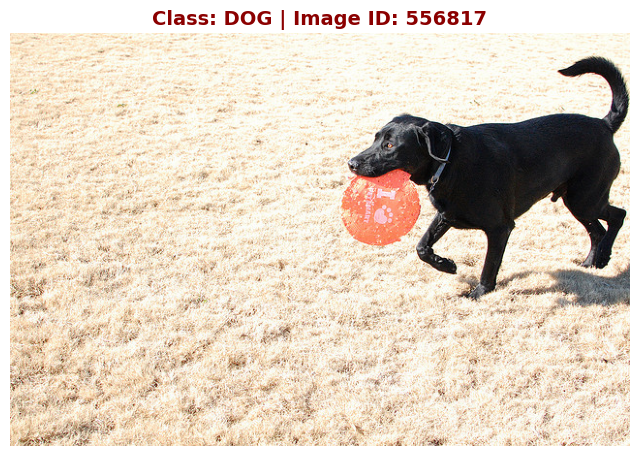


📝 5 CORRESPONDING CAPTIONS:
1. A dog carrying a ball in his mouth on the sand.
2. A black dog carrying a red frisbee in a field.
3. A black dog walking with a frisbee in his mouth.
4. A big black dog carrying a frisbee in its mouth.
5. there is a black dog on the beach with a frisbee


In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Lấy ngẫu nhiên 1 image_id thuộc class 'dog' từ DataFrame df_animal
# (Nếu bạn biết chính xác image_id của tấm hình chú chó bắt frisbee, hãy thay thẳng vào biến này)
sample_class = 'dog'
sample_image_id = df_animal_data[df_animal_data['class'] == sample_class]['image_id'].sample(1).values[0]

# Lọc ra tất cả các dòng chứa image_id này (thường COCO sẽ có khoảng 5 captions cho 1 ảnh)
sample_data = df_animal_data[df_animal_data['image_id'] == sample_image_id]
sample_captions = sample_data['caption'].tolist()

# Lấy đường dẫn ảnh (Lưu ý: đổi tên cột 'image_path' thành tên cột thực tế trong df của bạn nếu khác)
sample_image_path = sample_data['image_path'].iloc[0]

# 1. Hiển thị ảnh
plt.figure(figsize=(8, 6))
try:
    img = Image.open(sample_image_path)
    plt.imshow(img)
    plt.axis('off') # Tắt trục tọa độ cho đẹp
    plt.title(f"Class: {sample_class.upper()} | Image ID: {sample_image_id}", fontsize=14, fontweight='bold', color='darkred')
    plt.show()
except FileNotFoundError:
    print(f"⚠️ Không tìm thấy ảnh tại đường dẫn: {sample_image_path}")

# 2. In 5 captions ra màn hình
print("\n📝 5 CORRESPONDING CAPTIONS:")
print("=" * 60)
for i, caption in enumerate(sample_captions[:5], 1): # Giới hạn lấy 5 caption đầu tiên
    print(f"{i}. {caption}")
print("=" * 60)

In [13]:
print(f"Trước khi dọn dẹp: {len(df_animal_data)} dòng")

# 2. Xóa sổ các dòng trùng lặp (chỉ giữ lại 1 bộ 5 captions cho mỗi class trong 1 ảnh)
df_animal_data = df_animal_data.drop_duplicates(subset=['image_id', 'class', 'caption']).reset_index(drop=True)

print(f"Sau khi dọn dẹp (CHUẨN XÁC): {len(df_animal_data)} dòng")



Trước khi dọn dẹp: 110274 dòng
Sau khi dọn dẹp (CHUẨN XÁC): 46022 dòng


In [14]:

# Define the output CSV file name
output_csv_file = 'animal_classification_data.csv'

# Save the DataFrame to a CSV file
df_animal_data.to_csv(output_csv_file, index=False)

print(f"Data successfully saved to {output_csv_file}")

Data successfully saved to animal_classification_data.csv


In [15]:
import pandas as pd

# Load the animal_classification_data.csv file into a DataFrame
df_animal_data_sample = pd.read_csv('animal_classification_data.csv')

# Display the first 10 rows of the DataFrame
print("First 10 rows of animal_classification_data.csv:")
print(df_animal_data_sample.head(10))

First 10 rows of animal_classification_data.csv:
   image_id                                   image_path  \
0     16164  coco_data/images/train2017/000000016164.jpg   
1     16164  coco_data/images/train2017/000000016164.jpg   
2     16164  coco_data/images/train2017/000000016164.jpg   
3     16164  coco_data/images/train2017/000000016164.jpg   
4     16164  coco_data/images/train2017/000000016164.jpg   
5    205350  coco_data/images/train2017/000000205350.jpg   
6    205350  coco_data/images/train2017/000000205350.jpg   
7    205350  coco_data/images/train2017/000000205350.jpg   
8    205350  coco_data/images/train2017/000000205350.jpg   
9    205350  coco_data/images/train2017/000000205350.jpg   

                                             caption class  
0         A dog is laying on a dirty bathroom floor.   dog  
1      There is a dog sitting in the men's restroom.   dog  
2     A black and white dog laying next to a urinal.   dog  
3  Black and white dog laying in dirty public 

In [16]:
import pandas as pd

# Calculate the number of unique image_id for each 'class'
unique_image_counts = df_animal_data.groupby('class')['image_id'].nunique()

print("Number of unique images per class:")
print(unique_image_counts)


Number of unique images per class:
class
cat      3421
cow      1353
dog      2336
horse     933
sheep    1161
Name: image_id, dtype: int64


Number of unique images per class:
class
cat      3421
cow      1353
dog      2336
horse     933
sheep    1161
Name: image_id, dtype: int64


/tmp/ipykernel_731/778182086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_image_counts.index, y=unique_image_counts.values, palette='viridis')


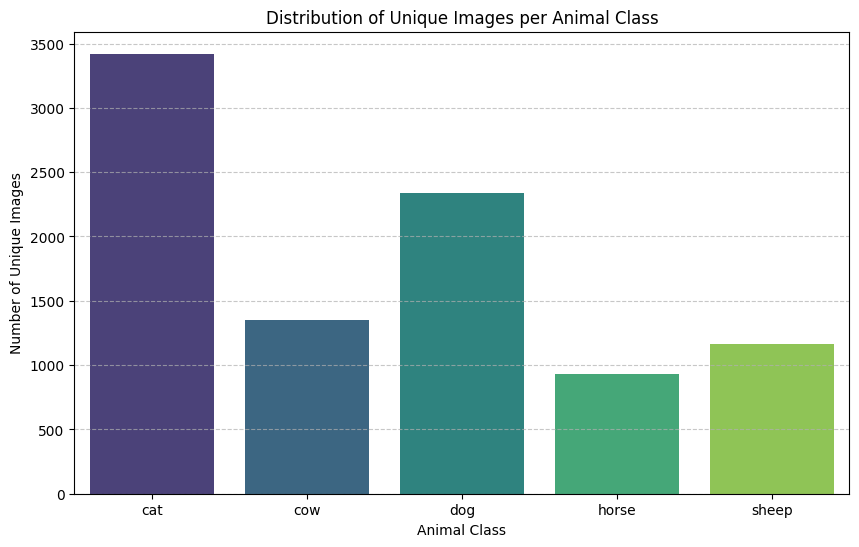

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of unique image_id for each 'class'
unique_image_counts = df_animal_data.groupby('class')['image_id'].nunique()

print("Number of unique images per class:")
print(unique_image_counts)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_image_counts.index, y=unique_image_counts.values, palette='viridis')
plt.title('Distribution of Unique Images per Animal Class')
plt.xlabel('Animal Class')
plt.ylabel('Number of Unique Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [18]:
print("\n--- DataFrame Info ---")
df_animal_data.info()

print("\n--- DataFrame Description ---")
print(df_animal_data.describe(include='all'))

print("\n--- Missing Values Count ---")
print(df_animal_data.isnull().sum())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46022 entries, 0 to 46021
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    46022 non-null  int64 
 1   image_path  46022 non-null  object
 2   caption     46022 non-null  object
 3   class       46022 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.4+ MB

--- DataFrame Description ---
             image_id                                   image_path  \
count    46022.000000                                        46022   
unique            NaN                                         8748   
top               NaN  coco_data/images/train2017/000000330022.jpg   
freq              NaN                                           15   
mean    291045.622507                                          NaN   
std     168665.447708                                          NaN   
min         42.000000                                    

Added 'caption_length' column to df_animal_data. First 5 entries:
                                             caption  caption_length
0         A dog is laying on a dirty bathroom floor.              42
1      There is a dog sitting in the men's restroom.              45
2     A black and white dog laying next to a urinal.              46
3  Black and white dog laying in dirty public res...              52
4  A dog sitting in a bathroom with a urinal and ...              58


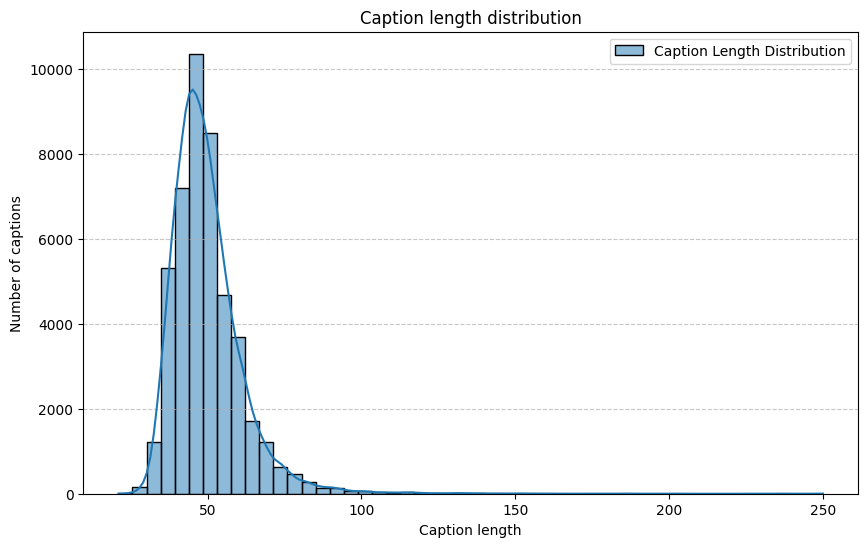

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the length of each caption and store it in a new column 'caption_length'
df_animal_data['caption_length'] = df_animal_data['caption'].str.len()

print("Added 'caption_length' column to df_animal_data. First 5 entries:")
print(df_animal_data[['caption', 'caption_length']].head())

# 2. Visualize the distribution of caption lengths using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_animal_data['caption_length'], bins=50, kde=True, label='Caption Length Distribution')
# 3. Set the title for the plot
plt.title('Caption length distribution')
# 4. Set labels for x-axis and y-axis
plt.xlabel('Caption length')
plt.ylabel('Number of captions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 5. Display the plot
plt.legend()
plt.show()

## Bước 1: Trích xuất và gộp Vector đại diện cho 5 classes (Text Encoder)

In [24]:
# Cài đặt thư viện (nếu chưa có)
!pip install git+https://github.com/openai/CLIP.git -q

import torch
import clip
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Dùng tqdm notebook cho hiển thị đẹp hơn
from collections import Counter
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Đang chạy trên thiết bị: {device}")

# Các cấu hình chính
K_SHOT = 5 # Số lượng captions đại diện cho mỗi class
clip_model_names = [
    "ViT-B/32",
    "ViT-B/16",
    "ViT-L/14",
    "RN50",
    "RN50x4",
    "RN50x16",
    "ViT-L/14@336px"
]

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
✅ Đang chạy trên thiết bị: cuda


In [25]:
print("BẮT ĐẦU TẢI TRỌNG SỐ CÁC MÔ HÌNH VỀ MÁY (CACHE)...")
print("Lưu ý: Quá trình này có thể mất 10-20 phút tùy tốc độ mạng do các model như RN50x16 rất nặng.\n")

for model_name in clip_model_names:
    print(f"⏳ Đang tải model: {model_name} ...", end=" ")
    try:
        # Load tạm lên CPU để ép thư viện tải file .pt về
        model, preprocess = clip.load(model_name, device="cpu")

        # Tải xong thì xóa luôn khỏi RAM để nhường chỗ cho model khác
        del model
        del preprocess
        print("✅ Xong!")
    except Exception as e:
        print(f"❌ Lỗi: {e}")

print("\n🎉 HOÀN TẤT TẢI TOÀN BỘ MÔ HÌNH!")

BẮT ĐẦU TẢI TRỌNG SỐ CÁC MÔ HÌNH VỀ MÁY (CACHE)...
Lưu ý: Quá trình này có thể mất 10-20 phút tùy tốc độ mạng do các model như RN50x16 rất nặng.

⏳ Đang tải model: ViT-B/32 ... 

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 63.6MiB/s]


✅ Xong!
⏳ Đang tải model: ViT-B/16 ... 

100%|███████████████████████████████████████| 335M/335M [00:05<00:00, 69.1MiB/s]


✅ Xong!
⏳ Đang tải model: ViT-L/14 ... 

...

✅ Xong!
⏳ Đang tải model: RN50x16 ... 

100%|███████████████████████████████████████| 630M/630M [00:51<00:00, 12.7MiB/s]


✅ Xong!
⏳ Đang tải model: ViT-L/14@336px ... 

100%|███████████████████████████████████████| 891M/891M [00:24<00:00, 38.9MiB/s]


✅ Xong!

🎉 HOÀN TẤT TẢI TOÀN BỘ MÔ HÌNH!


In [31]:
print("Đang chuẩn bị dữ liệu Test và lấy toàn bộ captions...")

# 1. Tạo tập Test (200 ảnh/class)
test_df = df_animal_data.groupby('class').apply(lambda x: x.sample(n=200, random_state=42)).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
true_labels = test_df['class'].tolist()

# 2. Lấy TOÀN BỘ captions cho mỗi class
classes = df_animal_data['class'].unique()
class_captions = {}

for c in classes:
    # Bỏ .sample(), chuyển thẳng toàn bộ cột caption của class đó thành list
    all_caps = df_animal_data[df_animal_data['class'] == c]['caption'].tolist()
    class_captions[c] = all_caps

print(f"✅ Đã chuẩn bị {len(test_df)} ảnh test và lấy TOÀN BỘ captions cho mỗi class!")

Đang chuẩn bị dữ liệu Test và lấy toàn bộ captions...
✅ Đã chuẩn bị 1000 ảnh test và lấy TOÀN BỘ captions cho mỗi class!


/tmp/ipykernel_731/3328533271.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df_animal_data.groupby('class').apply(lambda x: x.sample(n=200, random_state=42)).reset_index(drop=True)


In [34]:
BATCH_SIZE = 256 # Giảm số này xuống 128 hoặc 64 nếu vẫn gặp OOM

results = {}
all_predictions = {model_name: [] for model_name in clip_model_names}

for model_name in clip_model_names:
    print(f"\n{'-'*50}")
    print(f"🚀 Đang chạy inference bằng: {model_name}")

    # 1. Nạp model lên GPU
    model, preprocess = clip.load(model_name, device=device)
    model.eval()
    num_params = sum(p.numel() for p in model.parameters()) / 1e6 # Triệu tham số

    # 2. Sinh Class Vectors (Xử lý hàng loạt bằng Batching để tránh OOM)
    class_vectors = {}
    with torch.no_grad():
        for c, captions in class_captions.items():
            all_text_features = []

            # Chia nhỏ list captions thành các batch
            for i in range(0, len(captions), BATCH_SIZE):
                batch_caps = captions[i:i+BATCH_SIZE]

                # Thêm truncate=True phòng trường hợp có caption vượt quá 77 tokens của CLIP
                text_tokens = clip.tokenize(batch_caps, truncate=True).to(device)

                # Encode text
                batch_features = model.encode_text(text_tokens)

                # Chuẩn hóa từng vector ngay trong batch
                batch_features = batch_features / batch_features.norm(dim=-1, keepdim=True)
                all_text_features.append(batch_features)

            # Gộp tất cả features của class c lại (N x Embed_dim)
            text_features_concat = torch.cat(all_text_features, dim=0)

            # Lấy mean và chuẩn hóa lại vector đại diện cuối cùng
            mean_vector = text_features_concat.mean(dim=0)
            mean_vector = mean_vector / mean_vector.norm(dim=-1, keepdim=True)
            class_vectors[c] = mean_vector

    class_names_ordered = list(class_vectors.keys())
    text_weights = torch.stack([class_vectors[c] for c in class_names_ordered])

    # 3. Dự đoán trên Test Set
    preds = []
    total_inference_time = 0.0

    for img_path in tqdm(test_df['image_path'], desc="Tiến độ"):
        image = Image.open(img_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)

        start_time = time.time()
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = (100.0 * image_features @ text_weights.T).softmax(dim=-1)
            best_idx = similarity[0].argmax().item()
            pred_class = class_names_ordered[best_idx]

        end_time = time.time()
        total_inference_time += (end_time - start_time) * 1000
        preds.append(pred_class)

    all_predictions[model_name] = preds
    acc = accuracy_score(true_labels, preds)
    avg_infer_time = total_inference_time / len(test_df)

    results[model_name] = {
        "Accuracy": acc,
        "Params (M)": num_params,
        "Avg Inference Time (ms)": avg_infer_time,
        "Predictions": preds
    }

    print(f"📊 Kết quả {model_name} -> Acc: {acc:.4f} | Params: {num_params:.2f}M | Tốc độ: {avg_infer_time:.2f} ms/ảnh")

    # 4. Giải phóng bộ nhớ GPU (Cực kỳ quan trọng)
    del model
    del preprocess
    torch.cuda.empty_cache()


--------------------------------------------------
🚀 Đang chạy inference bằng: ViT-B/32


Tiến độ:   0%|          | 0/1000 [00:00<?, ?it/s]

📊 Kết quả ViT-B/32 -> Acc: 0.8840 | Params: 151.28M | Tốc độ: 9.31 ms/ảnh

--------------------------------------------------
🚀 Đang chạy inference bằng: ViT-B/16


Tiến độ:   0%|          | 0/1000 [00:00<?, ?it/s]

📊 Kết quả ViT-B/16 -> Acc: 0.9160 | Params: 149.62M | Tốc độ: 9.32 ms/ảnh

--------------------------------------------------
🚀 Đang chạy inference bằng: ViT-L/14


...

📊 Kết quả RN50x4 -> Acc: 0.9010 | Params: 178.30M | Tốc độ: 12.98 ms/ảnh

--------------------------------------------------
🚀 Đang chạy inference bằng: RN50x16


Tiến độ:   0%|          | 0/1000 [00:00<?, ?it/s]

📊 Kết quả RN50x16 -> Acc: 0.9240 | Params: 290.98M | Tốc độ: 18.94 ms/ảnh

--------------------------------------------------
🚀 Đang chạy inference bằng: ViT-L/14@336px


Tiến độ:   0%|          | 0/1000 [00:00<?, ?it/s]

📊 Kết quả ViT-L/14@336px -> Acc: 0.9380 | Params: 427.94M | Tốc độ: 23.89 ms/ảnh


In [35]:
print("Đang tổng hợp kết quả và tính Ensemble...")

ensemble_preds = []
# Duyệt qua từng ảnh, đếm vote từ tất cả model
for i in range(len(true_labels)):
    votes = [all_predictions[model][i] for model in results.keys()]
    most_common_class = Counter(votes).most_common(1)[0][0]
    ensemble_preds.append(most_common_class)

ensemble_acc = accuracy_score(true_labels, ensemble_preds)

# Tạo bảng dữ liệu bằng Pandas
summary_data = []
for k, v in results.items():
    summary_data.append({
        "Model": k,
        "Accuracy": v["Accuracy"],
        "Params (M)": round(v["Params (M)"], 2),
        "Inference Time (ms/img)": round(v["Avg Inference Time (ms)"], 2)
    })

# Thêm Ensemble vào bảng
summary_data.append({
    "Model": "🌟 Ensemble (Majority Vote)",
    "Accuracy": ensemble_acc,
    "Params (M)": sum(v["Params (M)"] for v in results.values()),
    "Inference Time (ms/img)": sum(v["Avg Inference Time (ms)"] for v in results.values())
})

summary_df = pd.DataFrame(summary_data)
display(summary_df) # Lệnh display giúp bảng in ra đẹp hơn print()

Đang tổng hợp kết quả và tính Ensemble...


,Model,Accuracy,Params (M),Inference Time (ms/img)
0,ViT-B/32,0.884,151.280000,9.310000
1,ViT-B/16,0.916,149.620000,9.320000
2,ViT-L/14,0.937,427.620000,17.010000
3,RN50,0.876,102.010000,8.430000
4,RN50x4,0.901,178.300000,12.980000
5,RN50x16,0.924,290.980000,18.940000
6,ViT-L/14@336px,0.938,427.940000,23.890000
7,🌟 Ensemble (Majority Vote),0.930,1727.745711,99.877679


Đang vẽ Confusion Matrix cho tất cả các mô hình...


/tmp/ipykernel_731/2681158716.py:49: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


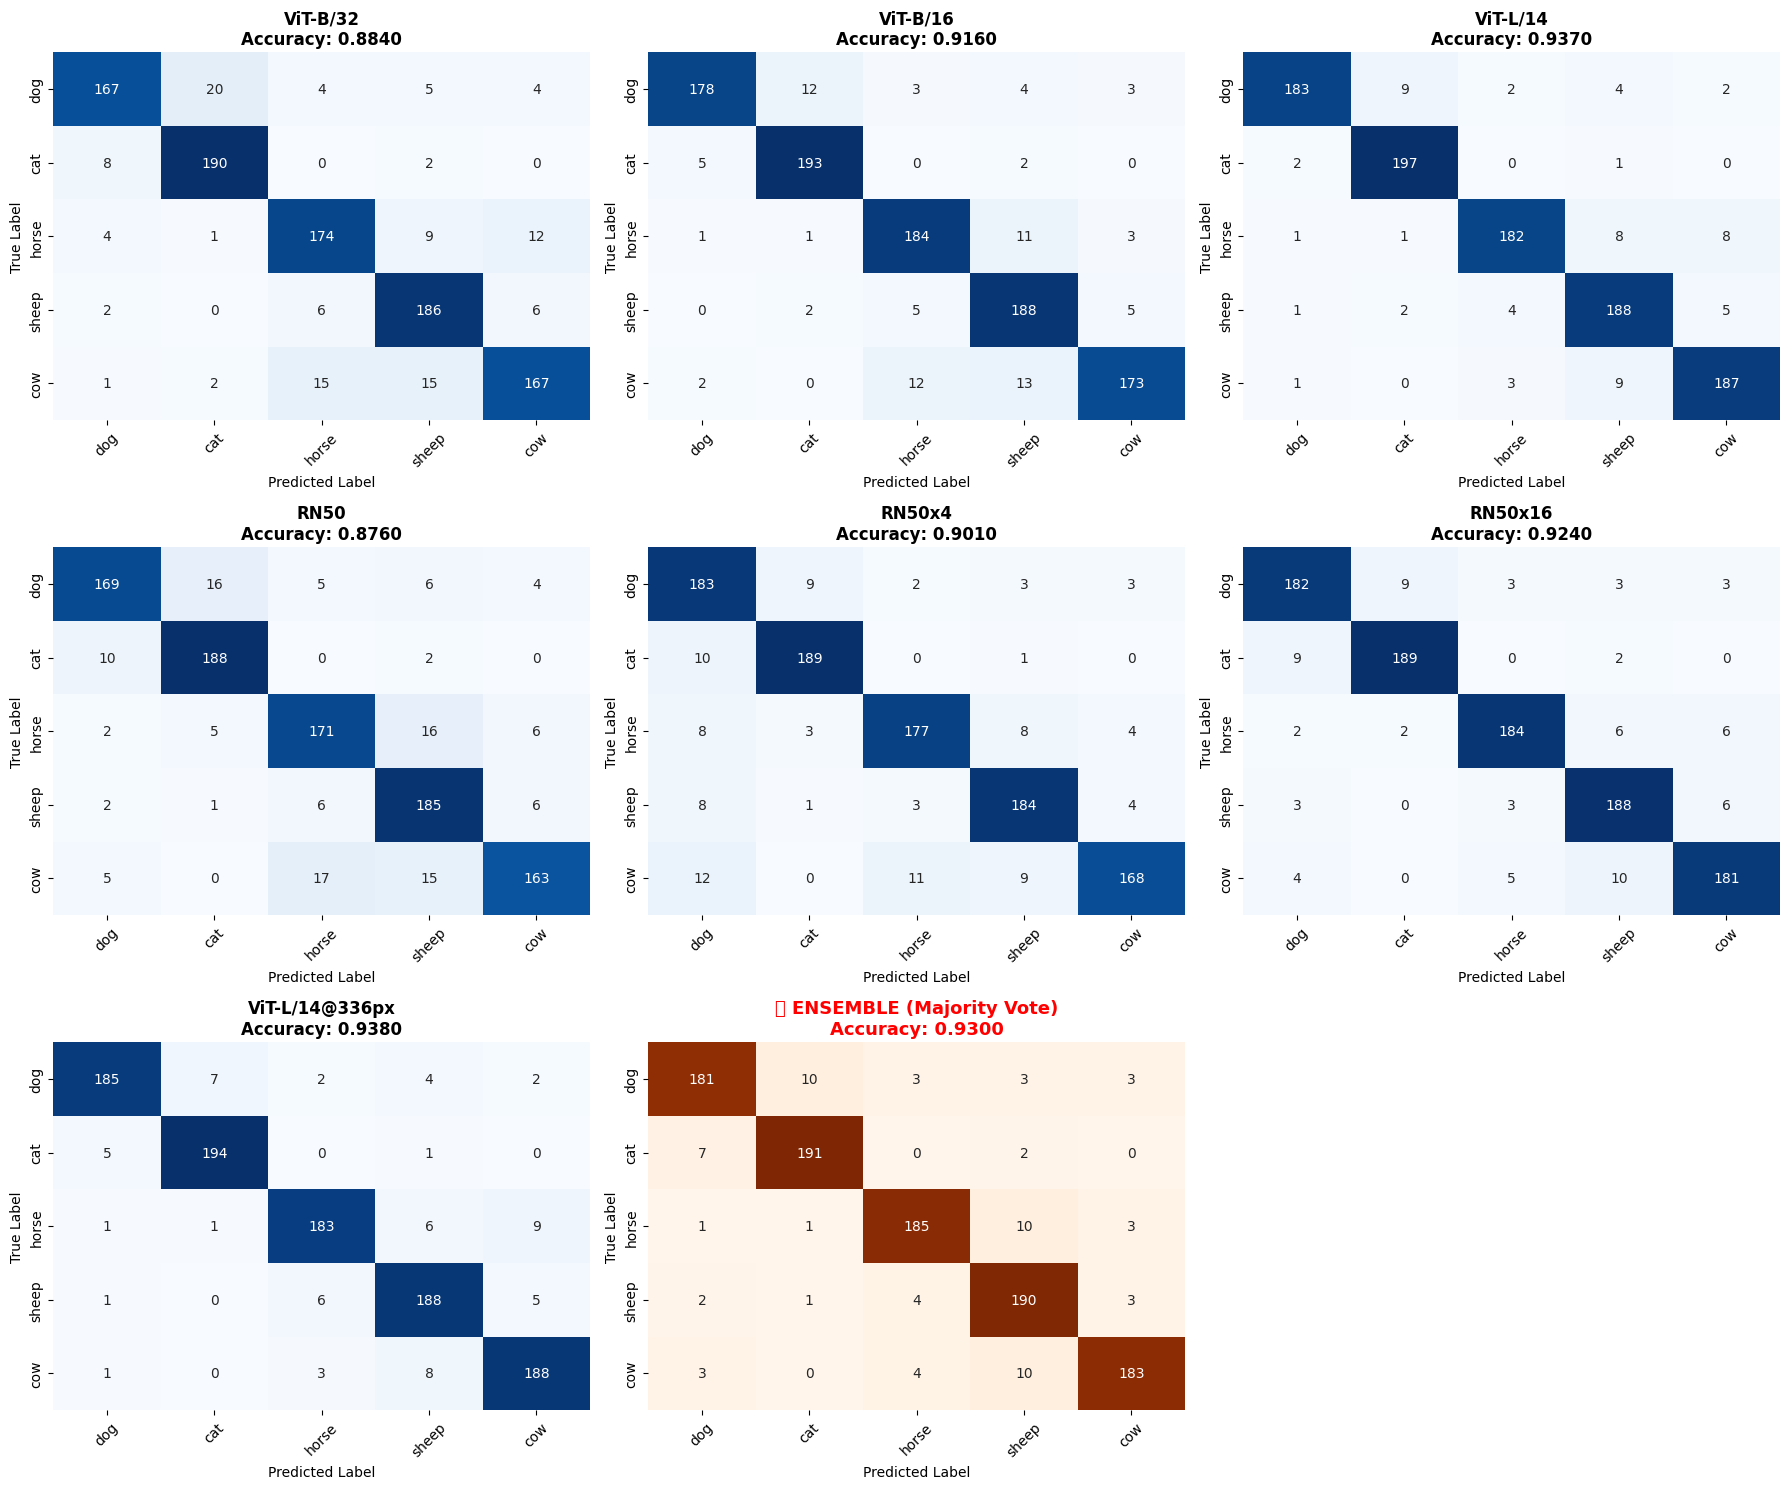

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Đang vẽ Confusion Matrix cho tất cả các mô hình...")

# Tính toán số lượng lưới vẽ cho phù hợp (Số models + 1 Ensemble)
num_plots = len(results) + 1
cols = 3 # 3 biểu đồ trên 1 hàng
rows = (num_plots + cols - 1) // cols

# Tạo figure bự để chứa hết các biểu đồ con
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

# Lấy danh sách tên các class để làm label
class_labels = list(classes)

# 1. Vẽ ma trận cho TỪNG MÔ HÌNH cá nhân
for idx, (model_name, data) in enumerate(results.items()):
    ax = axes[idx]
    cm = confusion_matrix(true_labels, data["Predictions"], labels=class_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels)

    ax.set_title(f"{model_name}\nAccuracy: {data['Accuracy']:.4f}", fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45) # Xoay chữ nghiêng 45 độ cho đỡ vướng

# 2. Vẽ ma trận cho mô hình ENSEMBLE
ax_ensemble = axes[len(results)]
cm_ensemble = confusion_matrix(true_labels, ensemble_preds, labels=class_labels)

sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax_ensemble,
            xticklabels=class_labels, yticklabels=class_labels)

ax_ensemble.set_title(f"🔥 ENSEMBLE (Majority Vote)\nAccuracy: {ensemble_acc:.4f}", fontsize=13, fontweight='bold', color='red')
ax_ensemble.set_ylabel('True Label')
ax_ensemble.set_xlabel('Predicted Label')
ax_ensemble.tick_params(axis='x', rotation=45)

# 3. Xóa các ô trống dư thừa (nếu tổng số biểu đồ không chia hết cho 3)
for i in range(len(results) + 1, len(axes)):
    fig.delaxes(axes[i])

# Căn chỉnh và show
plt.tight_layout()
plt.show()

In [38]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ccae009fc5eb329b889e53bfa6f79ba4c7ec5484e4c26cc5be6b011d66cd6cfb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# Cài đặt thư viện (nếu chưa có)
# !pip install grad-cam

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Chuẩn bị Grad-CAM cho mô hình RN50x16 (Few-Shot)...")

# 1. Định nghĩa Wrapper Model cho Few-Shot CLIP
class CLIPFewShotWrapper(torch.nn.Module):
    def __init__(self, clip_model, text_weights):
        super().__init__()
        self.visual = clip_model.visual
        # Đảm bảo text_weights có type float16/float32 tương ứng với model
        self.text_weights = text_weights.to(clip_model.dtype)

    def forward(self, x):
        # Lấy đặc trưng ảnh
        image_features = self.visual(x)
        if isinstance(image_features, tuple):
            image_features = image_features[0]

        # Chuẩn hóa ảnh
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Tính similarity scores (logits) bằng text_weights của Few-Shot
        logits = 100.0 * image_features @ self.text_weights.T
        return logits

# 2. Tải lại model RN50x16 và khởi tạo Wrapper
model_name = "RN50x16"
model, preprocess = clip.load(model_name, device=device)
model.eval()

# (Giả định biến text_weights và class_names_ordered đã có từ Cell 4)
# Khởi tạo model bọc
few_shot_model = CLIPFewShotWrapper(model, text_weights).to(device)

# Lớp Target layer cho RN50x16
target_layers = [few_shot_model.visual.layer4[-1].conv3]

# Khởi tạo GradCAM
cam = GradCAM(model=few_shot_model, target_layers=target_layers)

# 3. Tự động tìm các ảnh bị phân loại sai từ tập Test
# (Dùng kết quả đã lưu trong dict 'results' ở Cell 4)
misclassified_indices = []
for idx, (true_lbl, pred_lbl) in enumerate(zip(true_labels, results[model_name]["Predictions"])):
    if true_lbl != pred_lbl:
        misclassified_indices.append(idx)

# Lấy ngẫu nhiên 5 ảnh sai để vẽ (tránh vẽ quá nhiều gây giật máy)
import random
random.seed(42)
sample_misclassified = random.sample(misclassified_indices, min(5, len(misclassified_indices)))

if not sample_misclassified:
    print("Tuyệt vời, mô hình không dự đoán sai ảnh nào để hiển thị Grad-CAM!")
else:
    print(f"Hiển thị Grad-CAM cho {len(sample_misclassified)} hình ảnh bị phân loại sai...")

    fig, axes = plt.subplots(len(sample_misclassified), 2, figsize=(10, 5 * len(sample_misclassified)))
    if len(sample_misclassified) == 1:
        axes = np.array([axes])

    for i, idx in enumerate(sample_misclassified):
        img_path = test_df['image_path'].iloc[idx]
        true_lbl = true_labels[idx]
        pred_lbl = results[model_name]["Predictions"][idx]

        # Lấy index của class dự đoán sai để làm Target cho GradCAM
        pred_class_index = class_names_ordered.index(pred_lbl)

        # Xử lý ảnh
        try:
            image = Image.open(img_path).convert("RGB")
            # Model RN50x16 có size đầu vào là 384x384
            img_tensor = preprocess(image).unsqueeze(0).to(device)

            # Khai báo mục tiêu cho GradCAM (tìm kiếm lý do tại sao nó lại đoán là pred_lbl)
            targets = [ClassifierOutputTarget(pred_class_index)]

            # Sinh Heatmap
            grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

            # Chuẩn bị ảnh nền để overlay
            img_np = np.array(image.resize((384, 384))).astype(np.float32) / 255.0
            cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            # Vẽ ảnh gốc
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title(f"Original\nTrue: {true_lbl}", fontsize=12)
            axes[i, 0].axis('off')

            # Vẽ ảnh Grad-CAM
            axes[i, 1].imshow(cam_img)
            axes[i, 1].set_title(f"Few-Shot Grad-CAM (RN50x16)\nPredicted: {pred_lbl}", fontsize=12, color='red')
            axes[i, 1].axis('off')

        except Exception as e:
            print(f"Lỗi khi xử lý ảnh {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Dọn dẹp GPU
del model
del few_shot_model
del cam
torch.cuda.empty_cache()